# Spike data PCA — stage 1 of the spike / LFP analysis

**Objective.** Describe the spiking of the sorted olfactory-bulb units on its own,
before any LFP is involved, and reduce the population to a handful of shared
activity modes that can later be compared against the LFP.

**What this notebook does**

1. Loads the sorted units from the NIX file, together with the protocol metadata
   (ketamine injection time, recording length).
2. Rasterises the spike trains to eyeball the session.
3. Converts every spike train into an instantaneous firing rate by convolving it
   with a 100 ms Gaussian kernel, sampled at 1 kHz so it lines up with the LFP.
4. Runs PCA over the neurons (samples = time bins, features = neurons) to get the
   dominant population modes.
5. Inspects the components: loadings (which neurons build each mode) and scores
   (how each mode evolves in time around the injection).
6. Caches the rates and the PCA to `../data/spike_pca.npz`, so that
   `combined_analysis.ipynb` never has to redo the slow rate estimate.

**Contents of the cache**

| key | shape | meaning |
| --- | --- | --- |
| `times` | `(n_time,)` | time axis of the rates, in seconds |
| `rates` | `(n_time, n_neurons)` | Gaussian-smoothed instantaneous rates, in Hz |
| `scores` | `(n_time, n_pc)` | projection of the rates onto each component |
| `loadings` | `(n_pc, n_neurons)` | neuron weights of each component |
| `ratio` | `(n_pc,)` | explained-variance fraction per component |
| `spike_ids` | `(n_neurons,)` | cluster id of each unit |
| `unit_labels` | `(n_neurons,)` | cluster id + SU/MU tag, for figure labels |
| scalars | — | `ketamine_time`, `recording_duration`, `kernel_sigma_ms`, `sampling_period_ms` |

`rates` and `scores` are stored as float32 to keep the file around 70 MB; that is
well below the precision the downstream correlations need.



## 0. Imports and configuration

Pull in the analysis stack and point the notebook at the data.

- **elephant / neo / quantities** — spike-train containers, the Gaussian rate
  estimate, and physical units, so times carry seconds rather than bare floats.
- **viziphant** — ready-made raster and rate-colormesh plots.
- **scikit-learn** — the PCA itself.
- `../source/utils.py` — shared plotting helpers (`use_analysis_style` sets the
  common figure style, `mark_event` draws the ketamine line, `plot_scree` draws
  the explained-variance curve) and the colours used across both notebooks.

`SPIKE_PCA_FILE` is the cache written by the last cell and read by
`combined_analysis.ipynb`.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import quantities as pq
from elephant import kernels
from elephant.statistics import instantaneous_rate
from neo.io import NixIO
from sklearn.decomposition import PCA
from viziphant.rasterplot import rasterplot
from viziphant.statistics import plot_instantaneous_rates_colormesh
%matplotlib inline
sys.path.insert(0, "../source")
from utils import SPIKE_COLOR, mark_event, plot_scree, use_analysis_style

NIX_FILE = "../data/rat_retreat_meta_1kHz.nix"
SPIKE_PCA_FILE = "../data/spike_pca.npz"    # written at the end of this script

# Draw the figures inline in the interactive window. Same effect as the
# `%matplotlib inline` magic, but plain Python, so the editor does not flag it.
plt.switch_backend("module://matplotlib_inline.backend_inline")
use_analysis_style()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

## 1. Load the units and read the experiment metadata from the file

Read the single segment of the NIX file and recover the protocol.

`seg.description` is a `"key=value; key=value"` string holding the protocol, e.g.
`"ketamine_injection_time_s=372; baseline_interval_s=0-372; ..."`, so it is parsed
into a dict to get the injection time.

The analog signal gives the ground-truth recording length. Each `SpikeTrain`
stores its own `t_stop` (the time of its *last spike*), which would otherwise
truncate quiet units to different lengths — so all trains are stretched to the
recording duration before rasterising or estimating rates.

Unit labels combine the cluster id with an SU/MU tag (single vs multi unit) and
are reused on every figure axis.

In [2]:
with NixIO(NIX_FILE, mode="ro") as io:
    block = io.read_block()

seg = block.segments[0]

# seg.description is a "key=value; key=value" string holding the protocol, e.g.
# "ketamine_injection_time_s=372; baseline_interval_s=0-372; ..."
metadata = dict(field.split("=", 1) for field in seg.description.split("; "))
ketamine_time = float(metadata["ketamine_injection_time_s"]) * pq.s
recording_duration = seg.analogsignals[0].t_stop    # ground truth for the session

# Each SpikeTrain stores its own t_stop (the time of its last spike), so align
# them to the recording length before rasterising / estimating rates.
sts = list(seg.spiketrains)
for st in sts:
    st.t_stop = recording_duration

n_neurons = len(sts)
spike_ids = [st.annotations["spike_id"] for st in sts]
unit_labels = [f"{st.annotations['spike_id']} "
               f"({'SU' if st.annotations['unit_type'] == 'single_unit' else 'MU'})"
               for st in sts]

print(f"{block.description} | {seg.description}")
print(f"recording: {recording_duration}, ketamine at {ketamine_time}")
print(f"{n_neurons} units (SU = single unit, MU = multi unit): {unit_labels}")

species=Rattus norvegicus; brain_region=olfactory bulb | ketamine_injection_time_s=372; baseline_interval_s=0-372; post_ketamine_interval_s=372-705.0; electrode_array=NeuroNexus 8x8; recording_type=extracellular electrophysiology
recording: 705.0 s, ketamine at 372.0 s
13 units (SU = single unit, MU = multi unit): ['32 (SU)', '36 (SU)', '38 (SU)', '40 (MU)', '31 (MU)', '41 (MU)', '39 (MU)', '35 (MU)', '51 (MU)', '7 (MU)', '48 (MU)', '60 (MU)', '18 (MU)']


## 2. Spike raster

Sanity check on the raw data: one tick per spike, one row per unit, with the
injection marked.

This is the plot to look at before trusting anything downstream — it shows which
units are alive for the whole session, whether any of them drop out, and whether
the firing visibly changes at the injection.

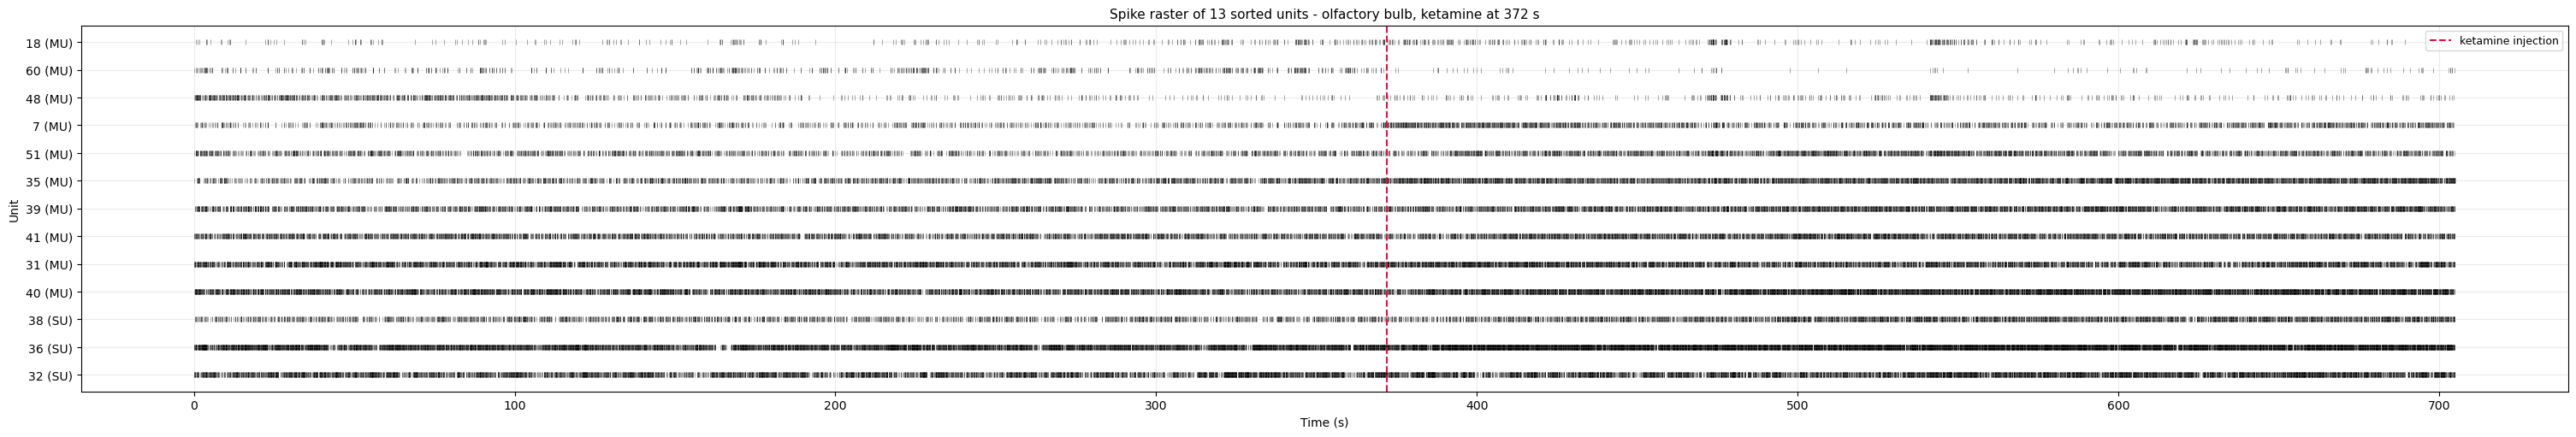

In [3]:
fig, ax = plt.subplots(figsize=(30, 5))
rasterplot(sts, axes=ax, s=20, marker="|", color="k", lw=0.5, alpha=0.5)
mark_event(ax, ketamine_time)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Unit")
ax.set_yticks(range(n_neurons))
ax.set_yticklabels(unit_labels)
ax.set_title(f"Spike raster of {n_neurons} sorted units - olfactory bulb, "
             f"ketamine at {float(ketamine_time):.0f} s")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## 3. Instantaneous firing rate (Gaussian kernel)

Turn the discrete spike trains into continuous firing rates, which is what PCA
needs as input.

Every spike is replaced by a Gaussian of width `sigma = 100 ms` and the result is
sampled every 1 ms — the same 1 kHz grid as the LFP, so the two modalities can be
correlated sample-by-sample later on. The kernel width sets the timescale the
analysis is sensitive to: 100 ms smooths out individual spikes but keeps
second-scale rate changes.

`units="s"` is passed to the colormesh on purpose: without it viziphant labels the
time axis in units of `sampling_period` (ms here) and the event marker would land
at 372 ms instead of 372 s.

instantaneous rate: (705000, 13) (n_time, n_neurons)


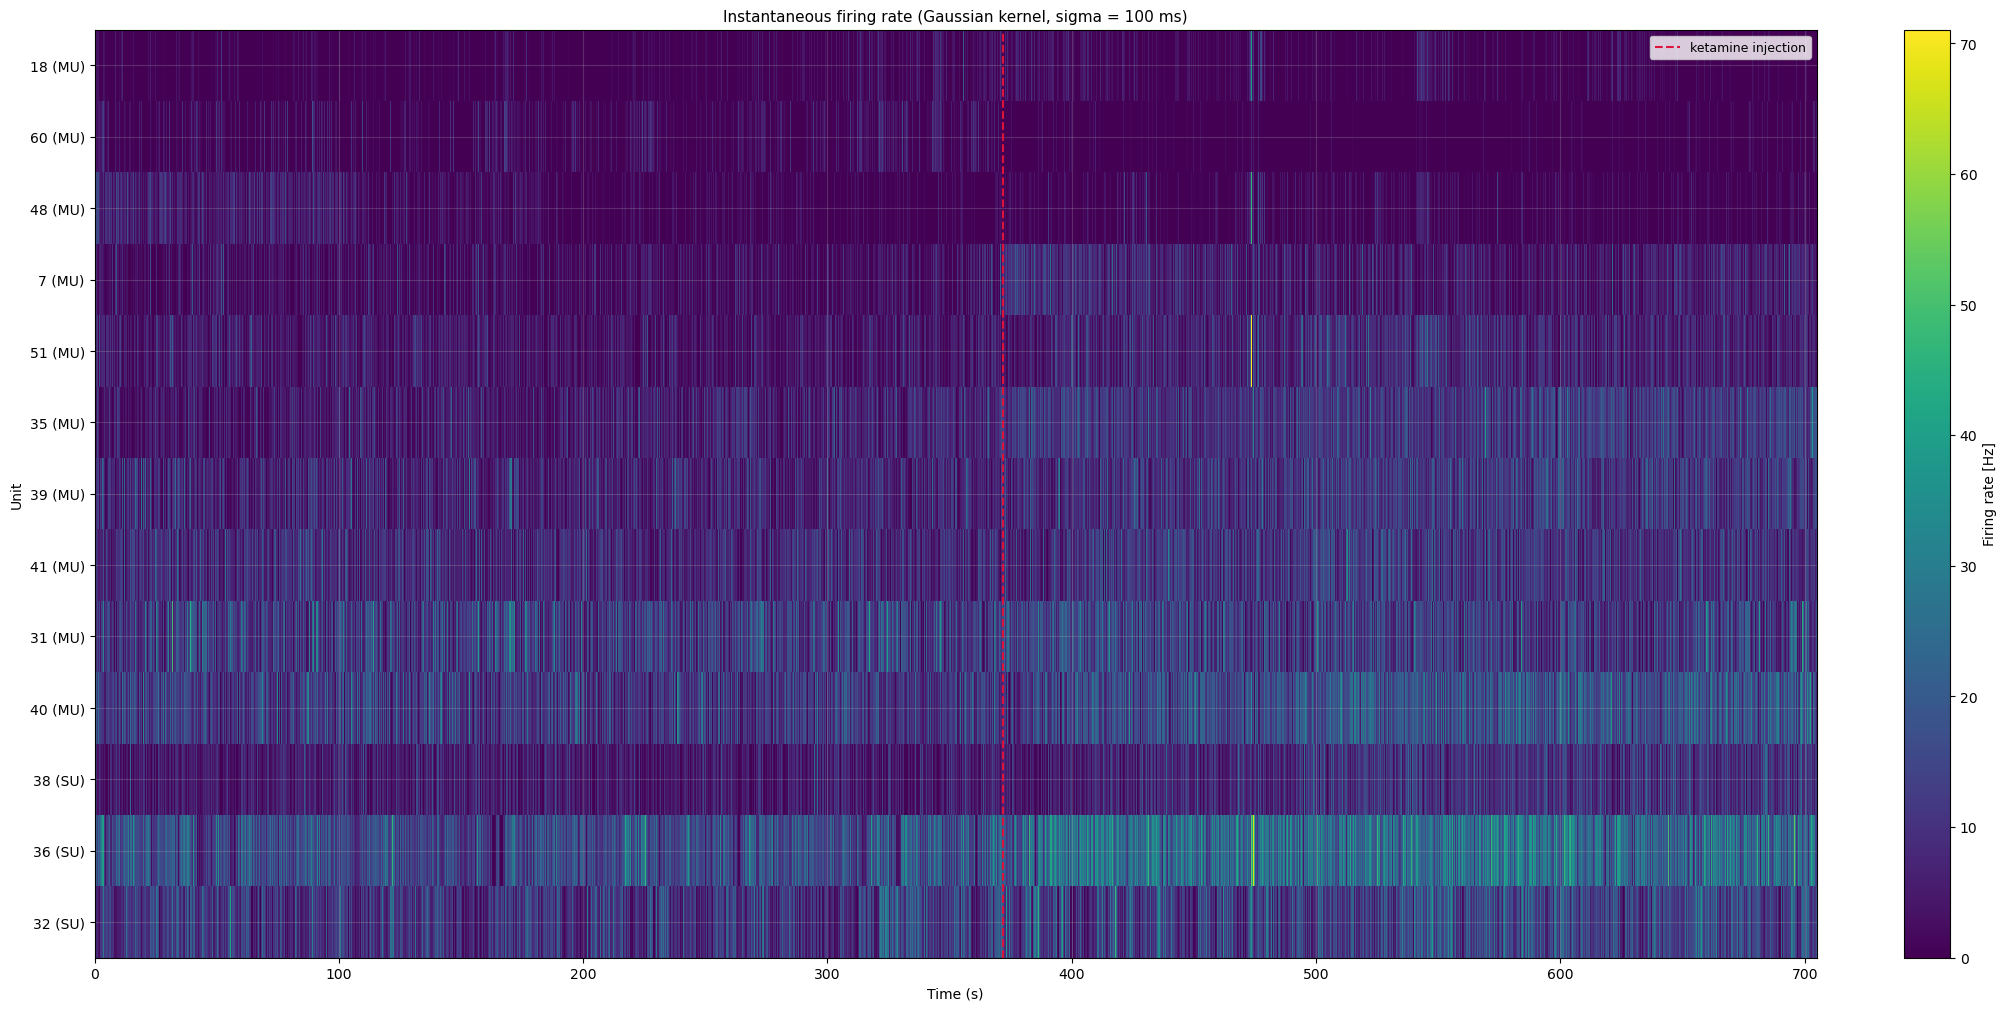

In [4]:
KERNEL_SIGMA = 100 * pq.ms          # smoothing width of the rate estimate
RATE_SAMPLING_PERIOD = 1 * pq.ms    # sample the rate at 1 kHz, like the LFP

kernel = kernels.GaussianKernel(sigma=KERNEL_SIGMA)
inst_rate = instantaneous_rate(sts, sampling_period=RATE_SAMPLING_PERIOD, kernel=kernel)
times_rate = inst_rate.times.rescale("s").magnitude
print(f"instantaneous rate: {inst_rate.shape} (n_time, n_neurons)")

fig, ax = plt.subplots(figsize=(20, 10))
# units="s": without it viziphant labels the time axis in the units of
# sampling_period (ms here) and the event marker would land at 372 ms.
plot_instantaneous_rates_colormesh(inst_rate, axes=ax, units="s")
mark_event(ax, ketamine_time)
# One mesh cell per unit, so the row centres sit at i + 0.5.
ax.set_yticks(np.arange(n_neurons) + 0.5)
ax.set_yticklabels(unit_labels)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Unit")
ax.set_title(f"Instantaneous firing rate (Gaussian kernel, "
             f"sigma = {KERNEL_SIGMA.item():.0f} ms)")
ax.legend(loc="upper right", fontsize=9)
plt.show()

## 4. PCA on the firing rates (samples = time bins, features = neurons)

Reduce the `n_neurons`-dimensional rate signal to its dominant modes.

Samples are time bins and features are neurons, so each component is a **spatial
pattern over the population** (a set of neuron weights) whose score is a time
series. Component 1 typically captures whatever the population does together —
e.g. a global rate change at the injection.

The scree plot reports how many components are needed to reach
`VARIANCE_THRESHOLD` (90 %) of the variance: a small number means the population
is highly redundant and a low-dimensional description is justified.

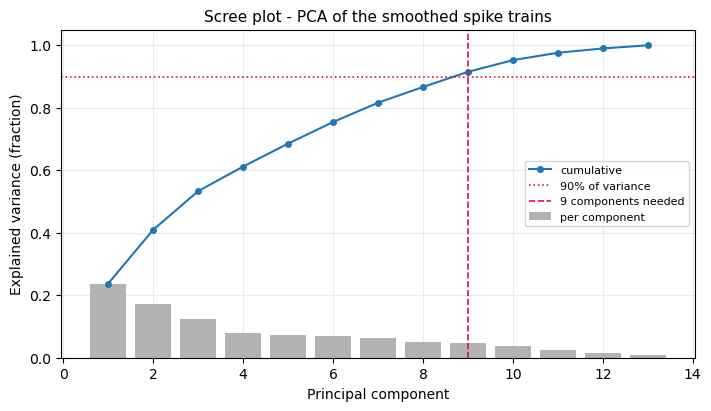

spikes: 9 components explain >90% of the variance
[0.237 0.409 0.533 0.612 0.685 0.754 0.816 0.867 0.915 0.952 0.976 0.99
 1.   ]


In [5]:
VARIANCE_THRESHOLD = 0.9    # cumulative variance target reported on the scree plot

pca_spike = PCA()
scores_spike = pca_spike.fit_transform(inst_rate.magnitude)   # (n_time, n_neurons)
loadings_spike = pca_spike.components_                        # (n_pc, n_neurons)
ratio_spike = pca_spike.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 4))
cum_spike, n_pc_spike = plot_scree(
    ratio_spike, "Scree plot - PCA of the smoothed spike trains", ax,
    threshold=VARIANCE_THRESHOLD)
plt.show()

print(f"spikes: {n_pc_spike} components explain >{VARIANCE_THRESHOLD:.0%} "
      f"of the variance")
print(np.round(cum_spike, 3))

## 5. Loadings - which neurons build each mode



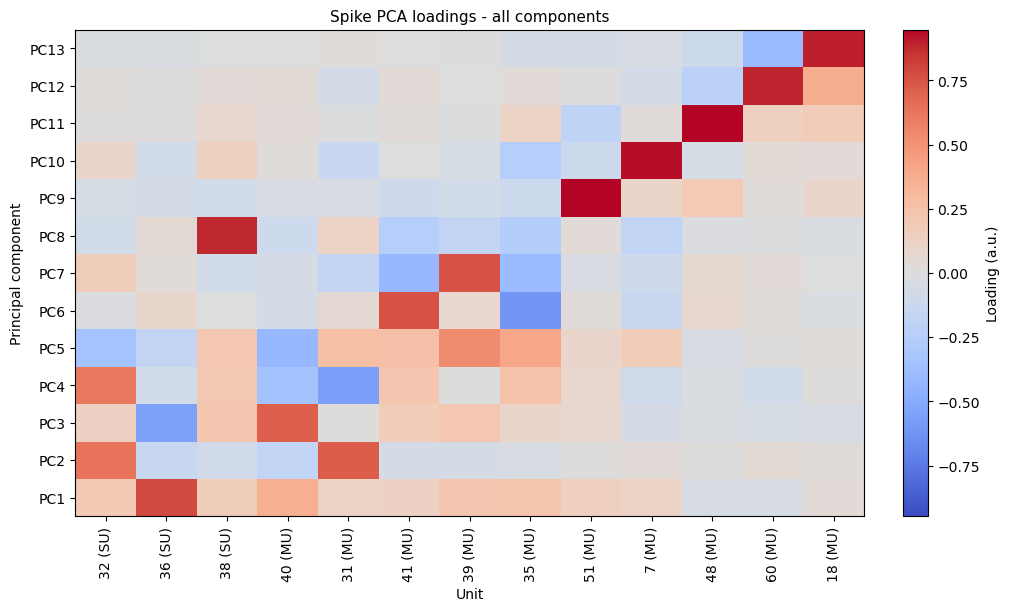

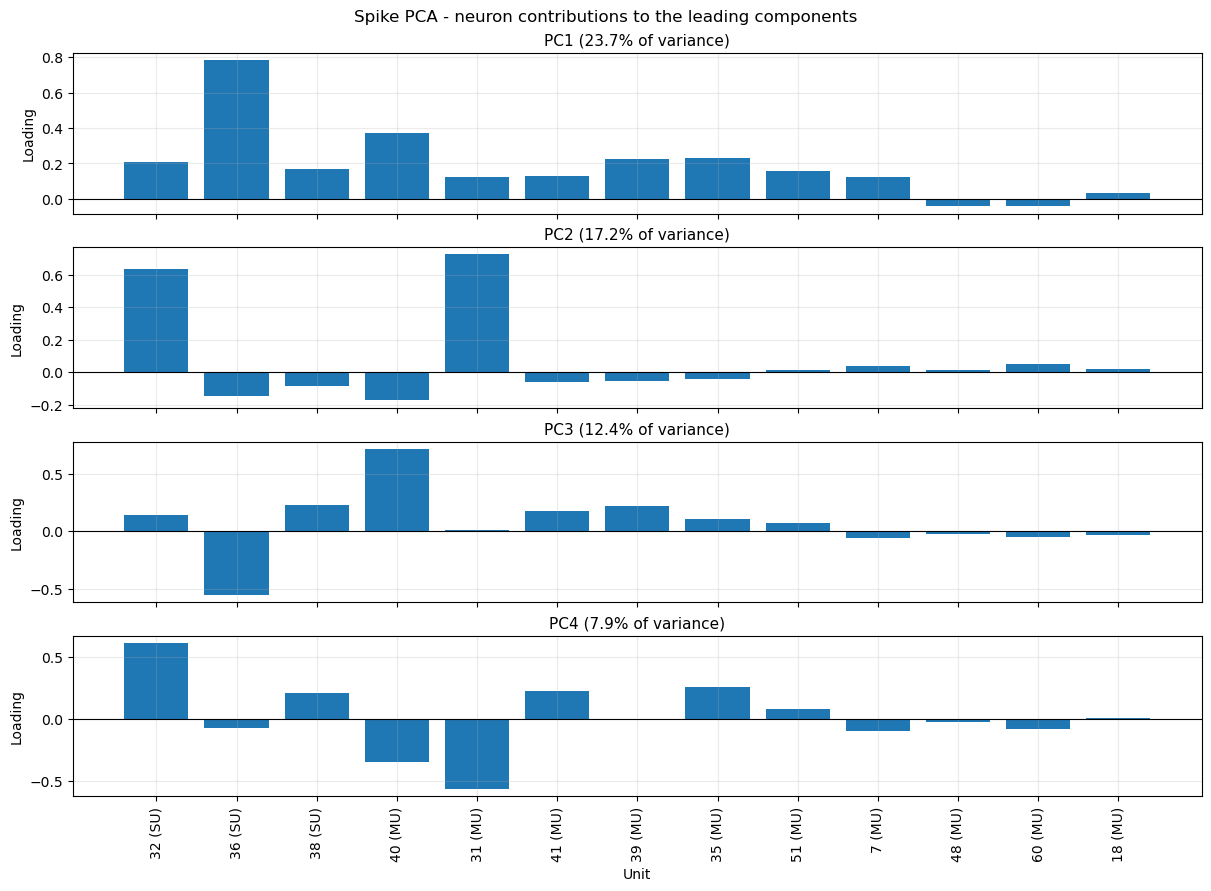

In [6]:
N_PCS_TO_SHOW = min(4, n_neurons)   # components shown in the detailed panels

# Full loading matrix: signed values -> diverging colormap, symmetric limits.
vmax = np.abs(loadings_spike).max()
fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(loadings_spike, cmap="coolwarm", vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(n_neurons) + 0.5, labels=unit_labels, rotation=90)
ax.set_yticks(np.arange(n_neurons) + 0.5,
              labels=[f"PC{i + 1}" for i in range(n_neurons)])
ax.grid(False)
ax.set_xlabel("Unit")
ax.set_ylabel("Principal component")
ax.set_title("Spike PCA loadings - all components")
fig.colorbar(mesh, ax=ax, label="Loading (a.u.)")
plt.show()

# Bar view of the leading components.
fig, axes = plt.subplots(N_PCS_TO_SHOW, 1, figsize=(12, 2.2 * N_PCS_TO_SHOW),
                         sharex=True)
for i, ax in enumerate(axes):
    ax.bar(np.arange(n_neurons), loadings_spike[i], color=SPIKE_COLOR)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("Loading")
    ax.set_title(f"PC{i + 1} ({ratio_spike[i]:.1%} of variance)")
axes[-1].set_xticks(np.arange(n_neurons), labels=unit_labels, rotation=90)
axes[-1].set_xlabel("Unit")
fig.suptitle("Spike PCA - neuron contributions to the leading components")
plt.show()

## 6. Score time courses

Read the same components in terms of time.

Each score is the projection of the whole population rate onto one mode, so this
is where the effect of the drug shows up: a component whose score shifts level,
changes variance, or starts oscillating after the marked injection time is a
population-level change, not a single-unit quirk.

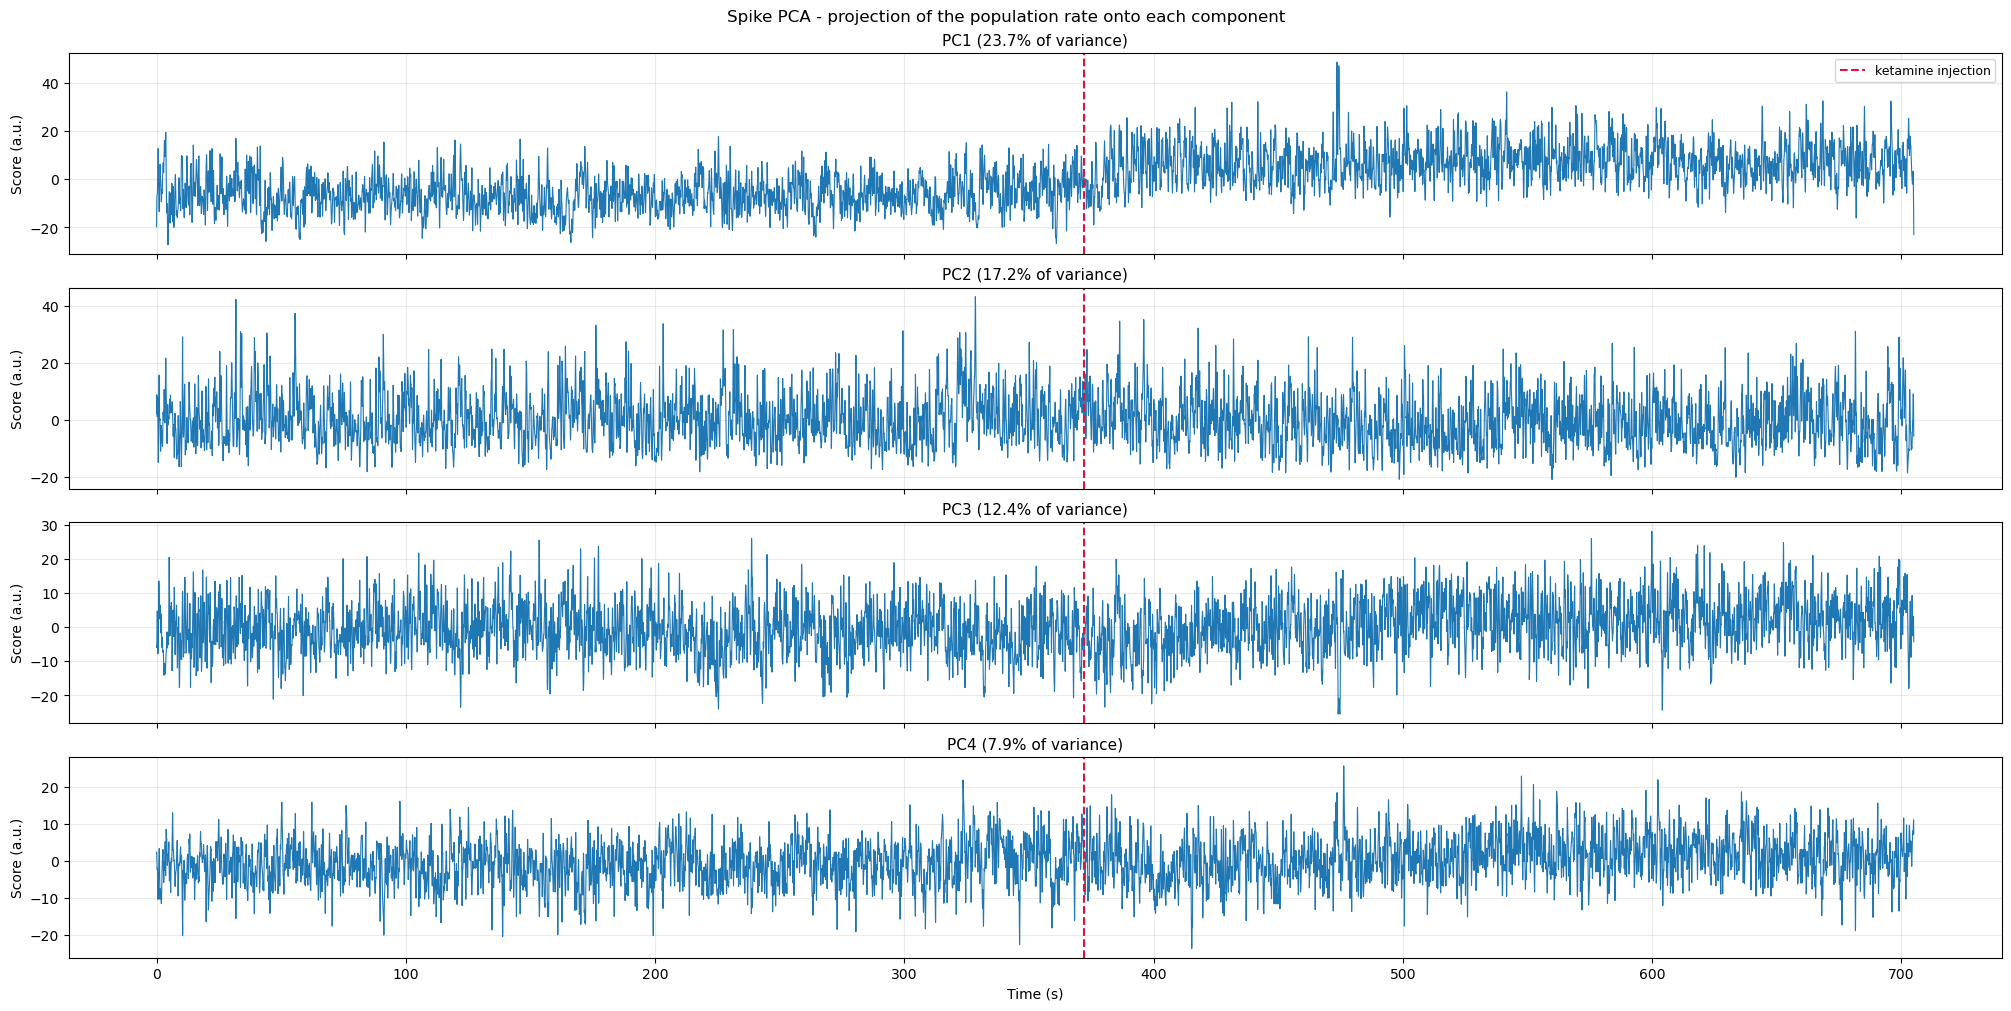

In [7]:
fig, axes = plt.subplots(N_PCS_TO_SHOW, 1, figsize=(20, 2.5 * N_PCS_TO_SHOW),
                         sharex=True)
for i, ax in enumerate(axes):
    ax.plot(times_rate, scores_spike[:, i], lw=0.8, color=SPIKE_COLOR)
    mark_event(ax, ketamine_time)
    ax.set_ylabel("Score (a.u.)")
    ax.set_title(f"PC{i + 1} ({ratio_spike[i]:.1%} of variance)")
axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Spike PCA - projection of the population rate onto each component")
plt.show()

## 7. Save the smoothed rates and the PCA for the combined analysis

Persist the expensive part of the pipeline.

The Gaussian rate estimate is by far the slowest step here, so the rates, the
scores, the loadings and the scalars describing the session are written to
`../data/spike_pca.npz`. `combined_analysis.ipynb` loads this file instead of
recomputing anything, which keeps stage 2 fast to iterate on.

`rates` and `scores` are cast to float32 to keep the archive around 70 MB.

In [8]:
np.savez(SPIKE_PCA_FILE,
         times=times_rate,
         rates=inst_rate.magnitude.astype(np.float32),
         scores=scores_spike.astype(np.float32),
         loadings=loadings_spike,
         ratio=ratio_spike,
         spike_ids=np.array(spike_ids),
         unit_labels=np.array(unit_labels),
         ketamine_time=float(ketamine_time),
         recording_duration=float(recording_duration),
         kernel_sigma_ms=float(KERNEL_SIGMA.rescale("ms")),
         sampling_period_ms=float(RATE_SAMPLING_PERIOD.rescale("ms")))

print(f"saved -> {SPIKE_PCA_FILE}")
print("next: run combined_analysis.py")

saved -> ../data/spike_pca.npz
next: run combined_analysis.py
